In [ ]:
from pathlib import Path
from glob import glob
import json
import xarray as xr
from numpy import allclose
from pandas import DataFrame, concat
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import cartopy.crs as ccrs
from pyrosm import OSM
import geopandas as gpd
from shapely.geometry import Point

import func_preparation as dbf
import func_stationary as dbst
import func_plotting as dbplt

# Introduction

Data shared contains **storm surge annual maxima data based on the DCPP simulations**. The folder contains 8 netcdf files, containing the data from 8 different models. 

Data is stored using **xarray**, which allows metadata, labels, and coordinates to be embedded directly in the files. As a result, the dataset should be largely self-explanatory and relatively easy to explore.

At each grid point (~ coastal site), there are **three possible bias corrections**: 
- coordinate *bc_flag indicates which bias correction should be used at each grid point*. 
- coordinate *model_valid* indicates whether the data from the model should be considered reliable at a given grid point.

Below, I have included a few simple examples showing how to interrogate the xarray Dataset and extract the data you may need, for convenience.


**Background information on the DCPP simulations**
  * https://confluence.ecmwf.int/display/CKB/CMIP6%3A+Decadal+climate+predictions




**linked packages**
  * https://docs.xarray.dev/en/stable/index.html

# Settings

In [ ]:
hindcast_start = 1960
hindcast_end = 2019

In [ ]:
# color palette finder https://python-graph-gallery.com/color-palette-finder/
colors = ['#7FF9F7FF', '#0B2483FF','#0F8CDEFF','#4C4CFFFF','#040509FF','#23B4DCFF','#3C7084FF']

In [ ]:
fs_title = 9.5

In [ ]:
path = '../input/Annual_max_DCPP_20260112/'

In [ ]:
export_dir_figures = Path("../output/exploration")

In [ ]:
save_site_plot = True
save_time_series_plot = True

In [ ]:
ls_messages = []

# Loading data

In [ ]:
ls_files = [file for file in glob(path + '*.nc')]
ls_files

['../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [ ]:
file_example = ls_files[-2]

In [ ]:
model_name = file_example.split('/')[-1].split('Annual_max_')[-1].split('.')[0]

ls_messages.append(f'Processing model: {model_name}')
model_name

'CanESM5'

In [ ]:
ds = xr.open_dataset(file_example, engine="netcdf4")

# Data Structure

In [ ]:
ds

<xarray.Dataset> Size: 349MB
Dimensions:      (sample: 660, member: 2, bc: 3, sites: 11022)
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 654 655 656 657 658 659
  * member       (member) int64 16B 1 2
  * bc           (bc) int64 24B 1 2 3
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) int64 5kB ...
    lead         (sample) int64 5kB ...
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...
Data variables:
    annualMax    (sample, member, bc, sites) float64 349MB ...
Attributes:
    description:  Modelled storm-surge annual maxima organized by simulated y...
    model:        CanESM5

In [ ]:
ls_messages.append(f'Dataset variables: {list(ds.data_vars)}')

for var in ds.data_vars:
    ls_messages.append(f' - {var}: {ds[var].attrs["long_name"]} [{ds[var].attrs["units"]}]')    

In [ ]:
ls_messages.append(f' - sim_year_range: {ds["sim_year"].to_series().describe().loc[["min", "max"]].astype(int).values}')

ds['sim_year'].to_series().describe().astype(int)

count     660
mean     1993
std        19
min      1961
25%      1977
50%      1993
75%      2010
max      2026
Name: sim_year, dtype: int64

In [ ]:
ls_messages

['Processing model: CanESM5',
 "Dataset variables: ['annualMax']",
 ' - annualMax: Storm-surge annual maxima [m]',
 ' - sim_year_range: [1961 2026]']

In [ ]:
ds.sample.sim_year == 2020

<xarray.DataArray 'sim_year' (sample: 660)> Size: 660B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])
Coordinates:
  * sample    (sample) int64 5kB 0 1 2 3 4 5 6 7 ... 653 654 655 656 657 658 659
    sim_year  (sample) int64 5kB 1961 1961 1961 1961 ... 2026 2026 2026 2026
    lead      (sample) int64 5kB ...

In [ ]:
ls_messages.append(f' - locations_total: {ds["sites"].shape[0]}')

ds['sites']

<xarray.DataArray 'sites' (sites: 11022)> Size: 88kB
array([    0,     1,     2, ..., 11019, 11020, 11021], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

In [ ]:
ds["bc_flag"].astype(int)-1 # per site

<xarray.DataArray 'bc_flag' (sites: 11022)> Size: 88kB
array([1, 1, 1, ..., 2, 2, 2], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

# Prepare Data 

### Bias Correction

In [ ]:
ds

<xarray.Dataset> Size: 349MB
Dimensions:      (sample: 660, member: 2, bc: 3, sites: 11022)
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 654 655 656 657 658 659
  * member       (member) int64 16B 1 2
  * bc           (bc) int64 24B 1 2 3
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) int64 5kB 1961 1961 1961 1961 ... 2026 2026 2026 2026
    lead         (sample) int64 5kB ...
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...
Data variables:
    annualMax    (sample, member, bc, sites) float64 349MB ...
Attributes:
    description:  Modelled storm-surge annual maxima organized by simulated y...
    model:        CanESM5

In [ ]:
annualMax_pref = xr.apply_ufunc(
    lambda v, i: v[i],
    ds["annualMax"],
    ds["bc_flag"].astype(int) - 1,
    input_core_dims=[["bc"], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[ds["annualMax"].dtype],
)

ls_messages.append(f'BiasCorrection with bc_flag successfully processed.')

#### Validation

original dimensions are: sample(time), member(ensemble/scenario?), bc, site(location)

In [ ]:
site = 100
sample = 500

In [ ]:
ds.annualMax[sample,:,:,site].values

array([[1.07831515, 0.96344943, 0.94338611],
       [0.89611038, 0.78124466, 0.78398053]])

In [ ]:
ds.annualMax.bc_flag[site].astype(int)-1

<xarray.DataArray 'bc_flag' ()> Size: 8B
array(1)
Coordinates:
    sites        int64 8B 100
    lon          float64 8B ...
    lat          float64 8B ...
    bc_flag      uint8 1B ...
    model_valid  bool 1B ...

In [ ]:
# Assert whether the bias correction works as expected 
# dimensions for ds.annualMax sample(time), member: 2, bc: 3, site-id
# dimensions for annualMax_pref sample(time), member: 2, site-id

expected = ds.annualMax[sample, :, ds.annualMax.bc_flag[site].astype(int)-1, site].values 
actual = annualMax_pref[sample, :, site].values

print(f"expected selection: {expected}... asserting whether actual: {actual} matches...")
assert allclose(actual, expected, equal_nan=True)

expected selection: [0.96344943 0.78124466]... asserting whether actual: [0.96344943 0.78124466] matches...


### Discarding non_valid data

In [ ]:
data_valid = annualMax_pref.where(ds.model_valid == True, drop=True)

In [ ]:
sites_valid = data_valid.shape[-1]
sites_total = annualMax_pref.shape[-1]
rate_invalid = (1 - sites_valid / sites_total) * 100

ls_messages.append(f'Selection of {sites_valid} valid locations - {rate_invalid:.2f}% invalid sites removed.')
print(
    f"From {sites_total} sites, only {sites_valid} are model valid; "
    f"{rate_invalid:.2f}% invalid sites removed."
    )

From 11022 sites, only 5782 are model valid; 47.54% invalid sites removed.


# Create pipeline for data import and preparation

In [ ]:
ls_files = [file for file in glob(path + '*.nc')]
ls_files

['../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [ ]:
def import_data_from_file(file):
    model_name = file.split('/')[-1].split('Annual_max_')[-1].split('.')[0]
    ds = xr.open_dataset(file, engine="netcdf4")
    
    return model_name, ds

def bias_correction(ds):
    return xr.apply_ufunc(
        lambda v, i: v[i], ds["annualMax"], ds["bc_flag"].astype(int) - 1,
        input_core_dims=[["bc"], []], output_core_dims=[[]],
        vectorize=True, dask="allowed", output_dtypes=[ds["annualMax"].dtype],
    )
    
def verify_bias_correction(ds_model, annualMax_pref):
    site = random.randint(0, ds_model.sites.shape[0]-1)
    sample = random.randint(0, ds_model.sample.shape[0]-1)

    expected = ds_model.annualMax[sample, :, ds_model.annualMax.bc_flag[site].astype(int)-1, site].values 
    actual = annualMax_pref[sample, :, site].values

    print(
        f" - Validating bias correction:\n"
        f"\tAsserting whether actual ({actual}) selection matches expected selection ({expected})... "
    )
    assert allclose(actual, expected, equal_nan=True)
    
    
def select_valid_data(ds_model, annualMax_pref):
    data_valid = annualMax_pref.where(ds_model.model_valid == True, drop=True)

    sites_valid = data_valid.shape[-1]
    sites_total = annualMax_pref.shape[-1]
    rate_invalid = (1 - sites_valid / sites_total) * 100

    return data_valid, sites_valid, sites_total, rate_invalid

In [ ]:
for en, file in enumerate(ls_files[:1]):
    
    model_name, ds_model = import_data_from_file(file) 
    print(f'Processing model: {model_name} ({en+1}/{len(ls_files)})...')
    
    ds_model_corrected = bias_correction(ds_model)
    verify_bias_correction(ds_model, ds_model_corrected)
    print(f' - Bias correction successfully done and verified.')

    data_valid, sites_valid, sites_total, rate_invalid = select_valid_data(ds_model, ds_model_corrected)
    print(
        f" - Site Selection done:\n"
        f"\tFrom {sites_total} sites, only {sites_valid} are model valid; {rate_invalid:.2f}% invalid sites removed."
    )

Processing model: MIROC6 (1/8)...
 - Validating bias correction:
	Asserting whether actual ([nan nan]) selection matches expected selection ([nan nan])... 
 - Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, only 7054 are model valid; 36.00% invalid sites removed.


# Visualizations

## Display Model Locations 
Which locations are we looking at? which one are valid?

In [ ]:
df = DataFrame([ds.lon.values, ds.lat.values, ds.model_valid.values], index=['lon', 'lat', 'model_valid']).T
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11022 entries, 0 to 11021
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   lon          11022 non-null  object
 1   lat          11022 non-null  object
 2   model_valid  11022 non-null  object
dtypes: object(3)
memory usage: 258.5+ KB


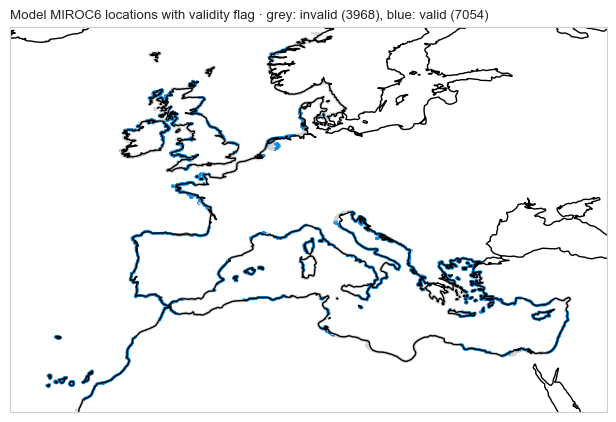

saving map to ../output/exploration as model_MIROC6_site_validity_map.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_title(
    f"Model {model_name} locations with validity flag · grey: invalid ({sites_total-sites_valid}), "
    f"blue: valid ({sites_valid})", 
    loc='left', fontsize=fs_title
    )

cmap = ListedColormap(["lightgrey", colors[2]])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

ax.scatter(
    df["lon"], df["lat"],
    c=df["model_valid"].astype(int), s=1, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_extent([-22, 40, 25, 65], crs=ccrs.PlateCarree()) 

plt.show()

if save_site_plot:
    export_dir_figures.mkdir(parents=True, exist_ok=True)
    file_name = f"model_{model_name}_site_validity_map.png"
    print(f"saving map to {export_dir_figures} as {file_name}")
    
    fig.savefig(
        export_dir_figures / file_name, dpi=300, bbox_inches='tight'
        )


## Display Timeseries at a specific location

1. Simulation year (init year)
This is the year when the model forecast was initialized.<br>
*Example: sim_year = 1995 means the model started from conditions in 1995.*

2. Lead time
How far into the future the model is predicting from the init year. Often in months or years.<br>
*Example:*
   - lead = 0 → initial state (or first forecast period)
   - lead = 1 → 1 year (or 1 month) after initialization
   - lead = 5 → 5 years after initialization

1. The actual time represented by a data point
The valid (verification) time is:
$valid year = sim year + lead$


**Questions to look at**<br>
A. *“What did the 1990 forecast predict over time?”* → Fix init year → see forecast evolution<br>
B. *“How good are 3-year lead forecasts across all hindcasts?”* → Fix lead time → compare across init years

In [ ]:
location_lookup = input(f"Inspect the closest value to a specific location ")

In [ ]:
location_lookup == ''

False

In [ ]:
from geopy.exc import GeocoderTimedOut
from geopy.geocoders import Nominatim
from geopy.location import Location

In [ ]:
if location_lookup == 'None' or location_lookup == '':
    print(f"No specific location selected.")
    location_closest = None
else:
    message = f'find closest location to {location_lookup}...'
    print(message)
    ls_messages.append(message)
    
    geolocator = Nominatim(user_agent="storm_surge_analysis", timeout=10)
    location_closest = geolocator.geocode(location_lookup)
    location_closest.latitude, location_closest.longitude
    
location_closest

find closest location to Almere...


Location(Almere, Flevoland, Nederland, (52.3705038, 5.2185859, 0.0))

In [ ]:
def find_closest_site_xr(sites_da, target_lat, target_lon):
    dist2 = (sites_da.lat - target_lat)**2 + (sites_da.lon - target_lon)**2
    
    idx_min = dist2.argmin().item()
    
    return {
        "index": idx_min,
        "site_id": sites_da.sites[idx_min].item(),
        "lat": sites_da.lat[idx_min].item(),
        "lon": sites_da.lon[idx_min].item()
    }

if location_closest:
    site_found = find_closest_site_xr(data_valid.sites, location_closest.latitude, location_closest.longitude)

    site_id = site_found['index']
    message = f'closest location found: {site_id}, {geolocator.reverse((site_found["lat"], site_found["lon"]))}'
    ls_messages.append(message)
    print(message)
else:
    site_id = 300
    
site_id

closest location found: 714, Farflerpad, De Steiger, Almere Haven, Almere, Flevoland, Nederland, 1351 AA, Nederland


714

In [ ]:
am_site = data_valid.isel(sites=site_id) # data_valid[:, :, site_id] - sample, member, annualMax

sim_years = am_site.sim_year.to_series().unique().astype(int)
lead = am_site.lead.to_series().unique()

In [ ]:
try:
    location = geolocator.reverse((am_site.lat.values, am_site.lon.values))
except: 
    location = None
location

Location(Farflerpad, De Steiger, Almere Haven, Almere, Flevoland, Nederland, 1351 AA, Nederland, (52.3518882, 5.2192017, 0.0))

In [ ]:
df_site = DataFrame(am_site.values, columns=['annualMax_member0', 'annualMax_member1'])
df_site['sim_year'] = DataFrame(am_site['sim_year'].values.astype(int))
df_site['lead'] = DataFrame(am_site['lead'].values.astype(int))
df_site['valid_year'] = df_site.sim_year + df_site.lead


message = f" - fetched annual maximum storm-surge with {df_site.dropna().shape[0]} valid samples out of {df_site.shape[0]} total samples."
ls_messages.append(message)
print(message)

df_site.dropna()

 - fetched annual maximum storm-surge with 529 valid samples out of 680 total samples.


,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
0,1.209270,0.812495,1961,1,1962
10,0.554427,0.889723,1962,1,1963
11,0.968407,0.924622,1962,2,1964
20,1.019230,0.895354,1963,1,1964
21,0.921193,0.843539,1963,2,1965
...,...,...,...,...,...
658,0.876732,0.756104,2026,9,2035
659,1.038113,0.960670,2026,10,2036
668,0.877595,0.831228,2027,9,2036
669,0.904448,1.016836,2027,10,2037


### A. “What did the *sim_year* forecast predict over time?”
Fix init year → see forecast evolution<br>

In [ ]:
sim_years

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028])

In [ ]:
sim_year_selected = random.choice(sim_years)
sim_year_selected

np.int64(1978)

In [ ]:
def select_location_data_with_inityear(df_site: DataFrame, sim_year_selected: int) -> DataFrame:
    return df_site[df_site.sim_year == sim_year_selected].sort_values('valid_year')

# ----------------------------------------------------

sim_year_forecast = select_location_data_with_inityear(df_site, sim_year_selected)
sim_year_forecast

,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
170,1.108306,1.197920,1978,1,1979
171,0.935868,0.923128,1978,2,1980
172,0.974522,0.836024,1978,3,1981
173,0.932132,0.814615,1978,4,1982
174,0.929274,0.993189,1978,5,1983
175,0.927188,0.947717,1978,6,1984
176,0.660414,1.023361,1978,7,1985
177,0.998303,1.001870,1978,8,1986
178,0.798236,0.706817,1978,9,1987
179,0.928766,0.593722,1978,10,1988


saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-1978_for_Nederland_52.352|5.219_model_MIROC6.png


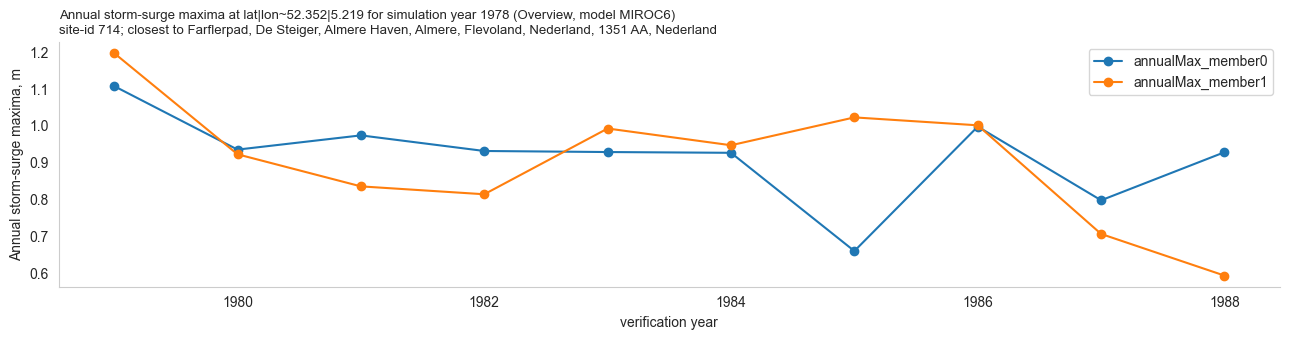

In [ ]:
def plot_forecast_timeseries_from_inityear_for_location( 
    sim_year_forecast: DataFrame, sim_year_selected: int, location: Location, site_id:int, model_name: str,
    save_time_series_plot: bool = True,  figsize=(13, 3.5), 
    ) -> plt.Figure:
    lat_str, lon_str = str(round(location[1][0], 3)), str(round(location[1][1], 3))
    country_str = location.address.split(',')[-1].strip()
    
    fig, ax = plt.subplots(figsize=figsize)
    title = "Annual storm-surge maxima at "
    title += f"lat|lon~{lat_str}|{lon_str} for simulation year {sim_year_selected} (Overview, model {model_name})"

    ax.set_title(
        title + f"\nsite-id {site_id}; closest to {location.address}" if location else f"site-id {site_id}", 
        loc='left', fontsize=fs_title
        )

    sim_year_forecast.set_index('valid_year').filter(like='annualMax').plot(ax=ax, marker='o')

    ax.set_ylabel('Annual storm-surge maxima, m')
    ax.set_xlabel('verification year')

    ax.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_time_series_plot:
        export_dir_figures.mkdir(parents=True, exist_ok=True)
        file_name = f"sim_year/forecast_with_simyear-{sim_year_selected}_for_{country_str}_{lat_str}|{lon_str}_model_{model_name}.png"
        print(f"saving map to {export_dir_figures/"sim_year"} as {file_name}")
        
        fig.savefig(
            export_dir_figures / file_name, dpi=300, bbox_inches='tight'
            )

    plt.close(fig)
    return fig

# ----------------------------------------------------

fig = plot_forecast_timeseries_from_inityear_for_location(
    sim_year_forecast, sim_year_selected, location, site_id, model_name,save_time_series_plot=True
    )
fig
    

#### Full run through all options

In [ ]:
years_selected_for_comparison = [1966, 1988, 1999, 2006, 2010, 2021, 2024, 2026, 2028]

In [ ]:
for sim_year_selected in years_selected_for_comparison: 
    sim_year_forecast = select_location_data_with_inityear(df_site, int(sim_year_selected))

    fig = plot_forecast_timeseries_from_inityear_for_location(
        sim_year_forecast, sim_year_selected, location, site_id, model_name,save_time_series_plot=True
        )


saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-1966_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-1988_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-1999_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-2006_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-2010_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-2021_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-2024_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration/sim_year as sim_year/forecast_with_simyear-2026_for_Nederland_52.352

### B. “How good are *x-year lead forecasts* across all hindcasts?”
Fix lead time → compare across init years

In [ ]:
lead_selected = random.choice(lead).astype(int)
lead_selected = 3

In [ ]:
def select_location_data_with_lead(df_site: DataFrame, lead_selected: int) -> DataFrame:
    lead_year_forecast = df_site[df_site.lead == lead_selected]
    return lead_year_forecast.sort_values('valid_year')

# ----------------------------------------------------

lead_year_forecast = select_location_data_with_lead(df_site, lead_selected)
lead_year_forecast

,annualMax_member0,annualMax_member1,sim_year,lead,valid_year
2,NaN,NaN,1961,3,1964
12,NaN,NaN,1962,3,1965
22,1.031091,1.904248,1963,3,1966
32,1.057389,0.876791,1964,3,1967
42,0.906192,0.789794,1965,3,1968
...,...,...,...,...,...
632,NaN,NaN,2024,3,2027
642,NaN,NaN,2025,3,2028
652,NaN,NaN,2026,3,2029
662,NaN,NaN,2027,3,2030


saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-3_for_Nederland_52.352|5.219_model_MIROC6.png


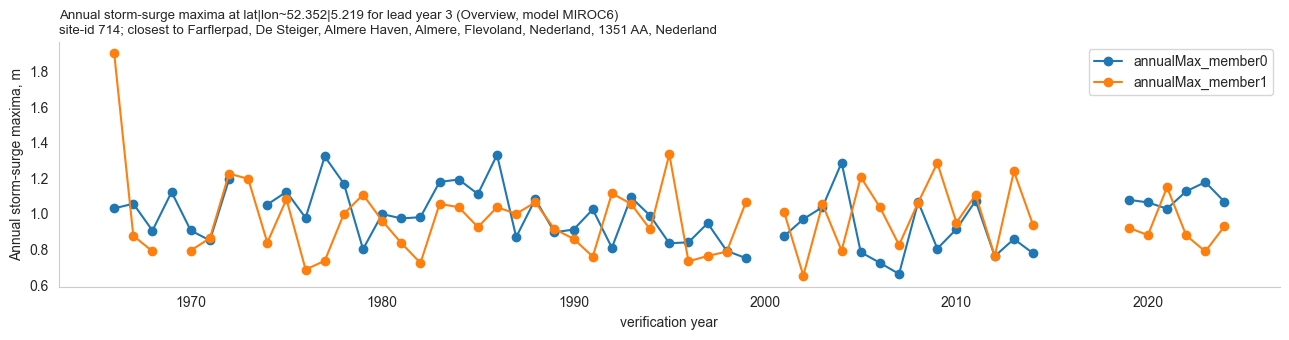

In [ ]:
def plot_forecast_quality_at_location_for_leadyear(
    lead_year_forecast: DataFrame, lead_selected: int, location: Location, site_id:int, model_name: str, 
    save_time_series_plot: bool = True, figsize=(13, 3.5), 
    ) -> plt.Figure:
    lat_str, lon_str = str(round(location[1][0], 3)), str(round(location[1][1], 3))
    country_str = location.address.split(',')[-1].strip()
    
    
    fig, ax = plt.subplots(figsize=figsize)
    
    title = "Annual storm-surge maxima at "
    title += f"lat|lon~{lat_str}|{lon_str} for lead year {lead_selected} (Overview, model {model_name})"

    ax.set_title(
        title + f"\nsite-id {site_id}; closest to {location.address}" if location else f"site-id {site_id}", 
        loc='left', fontsize=fs_title
        )

    lead_year_forecast.set_index('valid_year').filter(like='annualMax').plot(ax=ax, marker='o')

    ax.set_ylabel('Annual storm-surge maxima, m')
    ax.set_xlabel('verification year')

    ax.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_time_series_plot:
        export_dir_figures.mkdir(parents=True, exist_ok=True)
        file_name = f"lead/forecastQuality_at_leadyear-{lead_selected}_for_{country_str}_{lat_str}|{lon_str}_model_{model_name}.png"
        print(f"saving map to {export_dir_figures} as: {file_name}")
        
        fig.savefig(
            export_dir_figures / file_name, dpi=300, bbox_inches='tight'
            )
    plt.close(fig)
    return fig

# ----------------------------------------------------

fig = plot_forecast_quality_at_location_for_leadyear(
    lead_year_forecast, lead_selected, location, site_id, model_name, save_time_series_plot=True
    )

fig

#### Full run through all options

In [ ]:
for lead_selected in lead: 
    lead_year_forecast = select_location_data_with_lead(df_site, int(lead_selected))

    fig = plot_forecast_quality_at_location_for_leadyear(
        lead_year_forecast, int(lead_selected), location, site_id, model_name, save_time_series_plot=True
        )


saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-1_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-2_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-3_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-4_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-5_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-6_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-7_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/forecastQuality_at_leadyear-8_for_Nederland_52.352|5.219_model_MIROC6.png
saving map to ../output/exploration as: lead/for

# Lookup Location points

Mapping lon/lat to location info to speed up future usage.

Nominatim would need 4.5hours for 11022 locations... Searching for alternatives
| Need                            | Best approach              |
| ------------------------------- | -------------------------- |
| Country / state / county / city | **Spatial join (offline)** |
| Nearest town / place name       | **Photon API**             |
| Full formatted address          | **Mapbox / Google / HERE** |
| OSM-style labels                | **Photon or Pelias**       |
| One-time batch, reproducible    | **Offline shapefiles**     |


In [ ]:
ls_files

['../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [ ]:
dic_data_per_model = dict()

for en, file in enumerate(ls_files):
    model_name = file.split('/')[-1].split('.nc')[0].split('_')[-1]
    
    print(f'Importing data from model {model_name} ({en+1}/{len(ls_files)})...')
    model_name, ds_model = dbf.import_data_from_file(file) 
    
    dic_data_per_model[model_name] = dict({'raw data': ds_model})

Importing data from model MIROC6 (1/8)...
Importing data from model MPI-ESM1-2-HR (2/8)...
Importing data from model HadGEM3-GC31-MM (3/8)...
Importing data from model MRI-ESM2-0 (4/8)...
Importing data from model BCC-CSM2-MR (5/8)...
Importing data from model CMCC-CM2-SR5 (6/8)...
Importing data from model CanESM5 (7/8)...
Importing data from model NorCPM1 (8/8)...


Get unique locations from all models...

In [ ]:
locations = []
for model_ in dic_data_per_model.keys():
    locations.append(concat([
        dic_data_per_model[model_]['raw data'].lon.to_series(), 
        dic_data_per_model[model_]['raw data'].lat.to_series()
        ], axis=1).drop_duplicates().reset_index())

locations = concat(locations).drop_duplicates().reset_index()

locations.describe()

,index,sites,lon,lat
count,11022.000000,11022.000000,11022.000000,11022.000000
mean,5510.500000,5510.500000,4.870392,46.213890
std,3181.921668,3181.921668,12.515872,8.928387
min,0.000000,0.000000,-18.157674,25.184866
25%,2755.250000,2755.250000,-4.902126,37.970970
50%,5510.500000,5510.500000,0.453537,48.741868
75%,8265.750000,8265.750000,13.374634,53.621488
max,11021.000000,11021.000000,36.199925,64.368826


## Alternative to Nominatim for all 11022 locations

Download location info (OSM data) from https://download.geofabrik.de

In [ ]:
path_osm = '../input/osm_data/'

In [ ]:
ls_files_osm = [file for file in glob(path_osm + '*.osm.pbf')]
ls_files_osm

['../input/osm_data/europe-latest.osm.pbf',
 '../input/osm_data/africa-260122.osm.pbf']

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from pyrosm import OSM
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import json

In [ ]:
coastline_shp = "../input/osm_data/ne_10m_coastline/ne_10m_coastline.shp"  

coastal_buffer_m = 50000  # 50 km

points = [(lat, lon) for lat, lon in zip(locations.lat, locations.lon)]


In [ ]:
coastline = gpd.read_file(coastline_shp).to_crs("EPSG:3857")
coast_buffer = coastline.buffer(coastal_buffer_m)

coast_buffer_union = coast_buffer.unary_union
coast_buffer_gdf = gpd.GeoDataFrame(geometry=[coast_buffer_union], crs="EPSG:3857")


testing...

In [ ]:
gdf_list = []
lat_min, lat_max = locations.lat.min()-0.5, locations.lat.max()+0.5
lon_min, lon_max = locations.lon.min()-0.5, locations.lon.max()+0.5
bbox = [lat_min, lon_min, lat_max, lon_max]

for osm_file in ls_files_osm:
    print(f"\tFetching location information from {osm_file.split('/'){-1}}")
    
    osm = OSM(osm_file, bounding_box=bbox)
    
    places = osm.get_pois(custom_filter={"place": ["city", "town"]})
    if len(places) == 0:
        continue
    
    gdf = gpd.GeoDataFrame(places, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.to_crs("EPSG:3857")

    gdf = gdf[gdf.geometry.apply(lambda x: coast_buffer_union.contains(x))]
    gdf_list.append(gdf)

done until here... to be continued (if it ran successfully)...


In [ ]:
gdf_all = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))
sindex = gdf_all.sindex

points_gdf = gpd.GeoDataFrame(
    locations, geometry=[Point(lon, lat) for lat, lon in points], crs="EPSG:4326"
).to_crs("EPSG:3857")

def reverse_geocode_point(pt_row):
    pt = pt_row.geometry
    possible_idx = list(sindex.intersection(pt.bounds))
    possible_matches = gdf_all.iloc[possible_idx]
    for _, row in possible_matches.iterrows():
        if row.geometry.contains(pt):
            return {"name": row['name'], "type": row['place'], "lat": pt_row.lat, "lon": pt_row.lon}
    return {"name": None, "type": None, "lat": pt_row.lat, "lon": pt_row.lon}

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(reverse_geocode_point, [row for idx, row in points_gdf.iterrows()]))

#with open("locations.json", "w") as f:
#    json.dump(results, f, indent=2)


SyntaxError: unterminated string literal (detected at line 60) (2583169964.py, line 60)

screening locations - getting points for Africa took XY seconds

In [ ]:
gdf_list = []
for file in ls_files_osm[1:]:
    osm = OSM(file, bounding_box=[
        33.799356, -9.456281, 34.124546, -9.362611
        # locations.lat.min(), locations.lon.min(), locations.lat.max(), locations.lon.max()
        ])
    
    places = osm.get_pois(custom_filter={"place": ["city", "town"]})
    gdf_list.append(gpd.GeoDataFrame(places, geometry="geometry"))


: 

: 

In [ ]:
gdf_list

In [ ]:
gdf_all = gpd.GeoDataFrame(concat(gdf_list, ignore_index=True))
gdf_all = gdf_all.to_crs("EPSG:3857")
sindex = gdf_all.sindex

In [ ]:
points_gdf = gpd.GeoDataFrame(
    locations[['lat', 'lon']], columns=["lat", "lon"], geometry=[Point(lon, lat) for lat, lon in locations], crs="EPSG:4326"
)
points_gdf = points_gdf.to_crs("EPSG:3857")

def reverse_geocode_point(pt_row):
    pt = pt_row.geometry
    possible_idx = list(sindex.intersection(pt.bounds))
    possible_matches = gdf_all.iloc[possible_idx]
    for _, row in possible_matches.iterrows():
        if row.geometry.contains(pt):
            return {"name": row['name'], "type": row['place'], "lat": pt_row.lat, "lon": pt_row.lon}
    return {"name": None, "type": None, "lat": pt_row.lat, "lon": pt_row.lon}

from concurrent.futures import ThreadPoolExecutor
with ThreadPoolExecutor(8) as executor:
    results = list(executor.map(reverse_geocode_point, [row for idx, row in points_gdf.iterrows()]))

#with open("locations.json", "w") as f:
#    json.dump(results, f, indent=2)


: 

: 

## Nominatim 
Ok still *only* 11022 locations in total

In [ ]:
locations_label = dbf.locations_label_lookup_batched(locations) 